# Read LiveOcean Layers Icechunk Store

Opens the virtual Icechunk store created by `layers_icechunk.ipynb` in xarray.

In [1]:
import os
import icechunk
import xarray as xr

In [2]:
os.environ['AWS_REQUEST_CHECKSUM_CALCULATION'] = 'when_required'
os.environ['AWS_RESPONSE_CHECKSUM_VALIDATION'] = 'when_required'

In [3]:
storage_endpoint = "https://s3.kopah.uw.edu"
storage_bucket   = "liveocean-pmacc"
storage_name     = "icechunk-repo"
bucket_url       = f"s3://{storage_bucket}"

In [4]:
storage = icechunk.s3_storage(
    bucket=storage_bucket,
    prefix=f"icechunk_cas7_t2_x11b/{storage_name}",
    from_env=True,
    endpoint_url=storage_endpoint,
    region='not-used',
    force_path_style=True,
)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket_url}/",
        store=icechunk.s3_store(
            region="not-used",
            anonymous=False,
            s3_compatible=True,
            force_path_style=True,
            endpoint_url=storage_endpoint,
        ),
    )
)

credentials = icechunk.containers_credentials(
    {f"{bucket_url}/": icechunk.s3_credentials(anonymous=False)}
)

repo = icechunk.Repository.open(
    storage, config, authorize_virtual_chunk_access=credentials
)
session = repo.readonly_session("main")
print(repo)

<icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: S3 (native)
    bucket: liveocean-pmacc
    prefix: icechunk_cas7_t2_x11b/icechunk-repo
    region: not-used
    endpoint_url: https://s3.kopah.uw.edu
    force_path_style: True
config: <RepositoryConfig ...>



In [13]:
ds = xr.open_zarr(session.store, consolidated=False, chunks={})
#ds = xr.open_zarr(session.store, consolidated=False, chunks=None)
ds

<xarray.Dataset> Size: 18TB
Dimensions:          (ocean_time: 8785, s_w: 31, eta_rho: 1302, xi_rho: 663,
                      tracer: 14, s_rho: 30, boundary: 4, eta_u: 1302,
                      xi_u: 662, eta_v: 1301, xi_v: 663, eta_psi: 1301,
                      xi_psi: 662)
Coordinates:
  * ocean_time       (ocean_time) datetime64[ns] 70kB 2024-01-01 ... 2025-01-01
  * s_w              (s_w) float64 248B -1.0 -0.9667 -0.9333 ... -0.03333 0.0
    lat_rho          (eta_rho, xi_rho) float64 7MB ...
    lon_rho          (eta_rho, xi_rho) float64 7MB ...
  * s_rho            (s_rho) float64 240B -0.9833 -0.95 ... -0.05 -0.01667
    lat_u            (eta_u, xi_u) float64 7MB ...
    lon_u            (eta_u, xi_u) float64 7MB ...
    lat_v            (eta_v, xi_v) float64 7MB ...
    lon_v            (eta_v, xi_v) float64 7MB ...
    lat_psi          (eta_psi, xi_psi) float64 7MB ...
    lon_psi          (eta_psi, xi_psi) float64 7MB ...
Dimensions without coordinates: eta_rho, xi_rho, tracer, boundary, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/163)
    AKs              (ocean_time, s_w, eta_rho, xi_rho) float32 940GB ...
    AKv              (ocean_time, s_w, eta_rho, xi_rho) float32 940GB ...
    Akk_bak          float64 8B ...
    Akp_bak          float64 8B ...
    Akv_bak          float64 8B ...
    Charnok_alpha    float64 8B ...
    ...               ...
    wetdry_mask_psi  (ocean_time, eta_psi, xi_psi) float32 30GB ...
    wPhy             float64 8B ...
    xl               float64 8B ...
    zooplankton      (ocean_time, s_rho, eta_rho, xi_rho) float32 910GB ...
    zeta             (ocean_time, eta_rho, xi_rho) float32 30GB ...
    wetdry_mask_v    (ocean_time, eta_v, xi_v) float32 30GB ...
Attributes: (12/43)
    file:              /gscratch/macc/parker/LO_roms/cas7_t2_x11b/f2024.12.31...
    format:            netCDF-4/HDF5 file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             LiveOcean input file
    var_info:          /gscratch/macc/parker/LO_roms_source_git/ROMS/External...
    ...                ...
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            12x16
    history:           ROMS, Version 4.3, Sunday - March 29, 2026 -  4:57:13 AM
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_st...
    CPP_options:       X11B, ADD_FSOBC, ADD_M2OBC, ANA_BPFLUX, ANA_BSFLUX, AN...
    bio_file:          /gscratch/macc/parker/LO_roms_user/x11b/fennel.h

In [6]:
ds.ocean_time.values

array(['2026-01-01T00:00:00.000000000', '2026-01-01T01:00:00.000000000',
       '2026-01-01T02:00:00.000000000', '2026-01-01T03:00:00.000000000',
       '2026-01-01T04:00:00.000000000', '2026-01-01T05:00:00.000000000',
       '2026-01-01T06:00:00.000000000', '2026-01-01T07:00:00.000000000',
       '2026-01-01T08:00:00.000000000', '2026-01-01T09:00:00.000000000',
       '2026-01-01T10:00:00.000000000', '2026-01-01T11:00:00.000000000',
       '2026-01-01T12:00:00.000000000', '2026-01-01T13:00:00.000000000',
       '2026-01-01T14:00:00.000000000', '2026-01-01T15:00:00.000000000',
       '2026-01-01T16:00:00.000000000', '2026-01-01T17:00:00.000000000',
       '2026-01-01T18:00:00.000000000', '2026-01-01T19:00:00.000000000',
       '2026-01-01T20:00:00.000000000', '2026-01-01T21:00:00.000000000',
       '2026-01-01T22:00:00.000000000', '2026-01-01T23:00:00.000000000',
       '2026-01-02T00:00:00.000000000', '2026-01-02T01:00:00.000000000',
       '2026-01-02T02:00:00.000000000', '2026-01-02

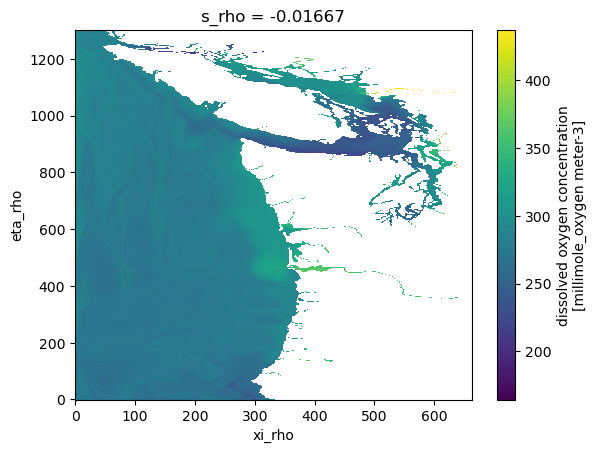

In [7]:
ds.oxygen[:,-1,:,:].mean(dim='ocean_time').plot()

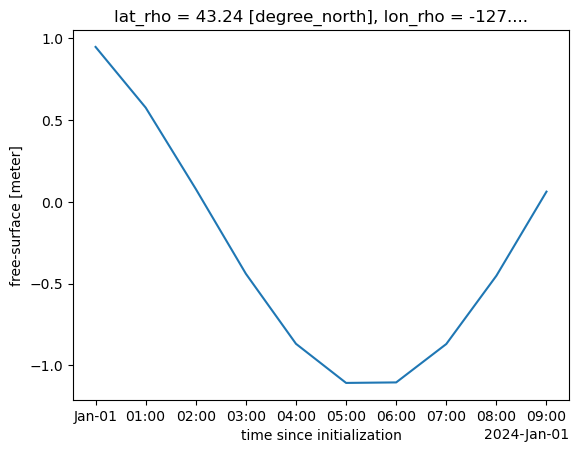

In [7]:
ds.zeta[:10,100,100].plot()

In [14]:
ds.oxygen

<xarray.DataArray 'oxygen' (ocean_time: 8785, s_rho: 30, eta_rho: 1302,
                            xi_rho: 663)> Size: 910GB
[227503212300 values with dtype=float32]
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 70kB 2024-01-01 ... 2025-01-01
  * s_rho       (s_rho) float64 240B -0.9833 -0.95 -0.9167 ... -0.05 -0.01667
    lat_rho     (eta_rho, xi_rho) float64 7MB ...
    lon_rho     (eta_rho, xi_rho) float64 7MB ...
Dimensions without coordinates: eta_rho, xi_rho
Attributes:
    standard_name:  mole_concentration_of_dissolved_oxygen_in_sea_water
    long_name:      dissolved oxygen concentration
    units:          millimole_oxygen meter-3
    time:           ocean_time
    cell_methods:   ocean_time: point
    grid:           grid
    location:       face
    field:          oxygen

In [16]:
ds.oxygen[::10,-1,100,100].values

array([264.30737, 264.8812 , 265.19333, 265.2916 , 266.11646, 265.8525 ,
       266.72168, 270.75522, 270.50735, 271.85147, 271.1941 , 271.17487,
       271.40637, 271.83725, 267.7548 , 271.3427 , 272.03253, 271.91803,
       271.98737, 272.8278 , 272.85822, 270.14676, 267.77704, 269.4138 ,
       268.68283, 266.78705, 267.57635, 267.35   , 268.74008, 270.35535,
       269.45035, 270.17136, 266.31406, 267.78906, 268.30035, 268.37585,
       267.8581 , 268.28943, 269.41144, 269.84238, 270.17477, 269.34015,
       269.71344, 270.98514, 271.24408, 271.38763, 269.88455, 271.93997,
       269.0267 , 271.5783 , 271.01566, 270.22922, 270.1554 , 270.18848,
       270.87823, 272.0882 , 271.6943 , 272.30438, 273.36472, 272.3946 ,
       274.09845, 272.58466, 273.67545, 272.87573, 273.0515 , 273.36127,
       273.53735, 273.24622, 272.63666, 272.8199 , 273.3002 , 273.70148,
       274.65222, 271.92123, 271.64548, 274.17545, 270.71368, 271.3618 ,
       272.10544, 272.17865, 273.14145, 272.9026 , 